In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, errno
import sys

In [61]:
#nº de pacotes no CPRI - 1: 761736/4 = 190434
p_dist = np.random.poisson(190434/4)
p_dist

47239

In [53]:
import random
random.expovariate(100)

0.027878793156252316

In [2]:
#settings
IPACT = {}
PD_DBA = {}
MPD_DBA = {}
loads = [768000, 1536000, 3072000]
CPRI_PKT = ['768000', '1536000', '3072000']

seeds = [20]
parameters = [{'w':10, 'p':3}, {'w':20, 'p':8}, {'w':15, 'p':3}]

In [3]:
for param in parameters:
    PD_DBA['{}-{}'.format(param['w'],param['p'])] = {}
    MPD_DBA['{}-{}'.format(param['w'],param['p'])] = {}

In [4]:
for param in parameters :
    for payload_size in CPRI_PKT:
        
        for seed in seeds:
            df_tmp = pd.read_csv("b_9000_t5/csv/delay/PD_DBA-dist{}-3ONUs-1OLTs-CBR_PG-exp0-pkt{}-w{}-p{}-s{}-delay.csv".format(
                    20, payload_size, param['w'], param['p'], seed))
            
        PD_DBA['{}-{}'.format(param['w'],param['p'])][payload_size] = df_tmp

In [5]:
#convertendo pra ms
for param in parameters:
    for payload_size in CPRI_PKT:
        PD_DBA['{}-{}'.format(param['w'], param['p'])][payload_size]['delay'] = PD_DBA['{}-{}'.format(param['w'], param['p'])][payload_size]['delay']*1000

In [6]:
PD_DBA['10-3']['768000'].describe()

,ONU_id,delay
count,760222.000000,760222.000000
mean,1.000391,3.420038
std,0.817742,6.265692
min,0.000000,0.101200
25%,0.000000,0.731924
50%,1.000000,1.508201
75%,2.000000,3.129367
max,2.000000,107.543315


In [7]:
aux = {'10-3':{}, '20-8':{}, '15-3':{}}

for param in parameters:
    for payload_size in CPRI_PKT:
        df_tmp = PD_DBA['{}-{}'.format(param['w'], param['p'])][payload_size]
        aux['{}-{}'.format(param['w'], param['p'])][payload_size] = df_tmp[df_tmp['delay']<=1.25]

In [8]:
for param in parameters:
    aux2 = []
    for payload_size in CPRI_PKT:
        
        aux['{}-{}'.format(param['w'], param['p'])][payload_size] = aux['{}-{}'.format(param['w'], param['p'])][payload_size].count()/PD_DBA['{}-{}'.format(param['w'], param['p'])][payload_size].count()
        aux['{}-{}'.format(param['w'], param['p'])][payload_size]['delay'] = aux['{}-{}'.format(param['w'], param['p'])][payload_size]['delay']*100
        aux2.append(aux['{}-{}'.format(param['w'], param['p'])][payload_size]['delay'])
    aux['{}-{}'.format(param['w'], param['p'])] = aux2

In [9]:
aux['10-3']

[42.42208197079274, 4.63714690834828, 1.0444989695661866]

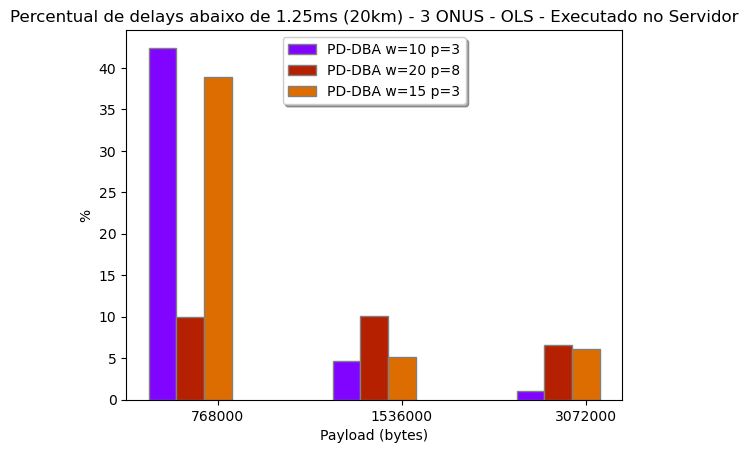

In [10]:
plt.figure()

title = "Percentual de delays abaixo de 1.25ms (20km) - 3 ONUS - OLS - Executado no Servidor"#figure title from argument
plt.title(title)
plt.xlabel("Payload (bytes)")
plt.ylabel("%")
number = 4
cmap = plt.get_cmap('gnuplot')
colors = [cmap(i) for i in np.linspace(0.25, 1, number)]

br = []
for j, param in enumerate(parameters):
    aux2 = aux['{}-{}'.format(param['w'], param['p'])]
    if len(br) != 0:
        br = [x+0.15 for x in br]
    else:
        br = np.arange(len(aux2))
    plt.bar(br, aux2, color=colors[j], edgecolor="grey", width=0.15, label="PD-DBA w={} p={}".format(param['w'],param['p']))

plt.xticks([r+0.30 for r in np.arange(len(aux2))], CPRI_PKT)

plt.legend(loc='upper center', shadow=True)
plt.show()
